# Stage 10b — Classification

This project has no per-row time series (`card_tiers.csv` carries no dates), so per the
rubric's "pick one track" this notebook does **classification**: predict whether a tier
is a high-value card ($100+) from its pull odds and type. The lag/rolling-feature
requirement is met along the **rarity ladder** (tiers ordered common -> rare within a
product), not a time axis.

In [9]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy pandas seaborn matplotlib scikit-learn

In [10]:
# Imports
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

np.random.seed(7); sns.set(); plt.rcParams['figure.figsize'] = (9, 4)

## Load project data & target

`data/raw/card_tiers.csv` (one row per hobby-box tier), joined to `packs_per_box` from
`box_products.csv`. Target: **`is_high_value = (est_value_usd >= 100)`** -- the tiers that
carry most of a box's EV. Features are tier-intrinsic (no per-product constants, no
leakage).

**Caveat:** `est_value_usd` is still the `rough_estimate_v0` ladder, so the label is a
near-deterministic function of the features and scores will be optimistic. This is a
reproducible baseline; it becomes real once `data/raw/tier_comps.csv` has eBay comps.

In [11]:
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_root))
ct = pd.read_csv(_root / "data" / "raw" / "card_tiers.csv")
bp = pd.read_csv(_root / "data" / "raw" / "box_products.csv")
df = ct.merge(bp[["product_id", "product_line", "packs_per_box"]], on="product_id", how="left")

df["log_odds_pack"] = np.log10(df["odds_pack"])
df["expected_hits_per_box"] = df["packs_per_box"] / df["odds_pack"]
for b in ["is_numbered", "is_autograph", "is_ssp"]:
    df[b] = df[b].astype(int)
for g in ["parallel", "insert", "auto", "variation"]:      # tg_base = reference level
    df[f"tg_{g}"] = (df["tier_group"] == g).astype(int)
df["is_high_value"] = (df["est_value_usd"] >= 100).astype(int)

model_df = df.dropna(subset=["log_odds_pack", "expected_hits_per_box"]).reset_index(drop=True)
print(f"{len(model_df)} rows | positive rate {model_df['is_high_value'].mean():.1%}")
model_df[["product_line", "tier_name", "log_odds_pack", "is_autograph",
          "est_value_usd", "is_high_value"]].head()

181 rows | positive rate 50.3%


,product_line,tier_name,log_odds_pack,is_autograph,est_value_usd,is_high_value
0,2025-26 Topps Chrome Basketball,Base Refractor,0.477121,0,3.0,0
1,2025-26 Topps Chrome Basketball,Prism Refractor,0.698970,0,3.0,0
2,2025-26 Topps Chrome Basketball,Wave Refractor,1.146128,0,3.0,0
3,2025-26 Topps Chrome Basketball,Negative Refractor,1.491362,0,8.0,0
4,2025-26 Topps Chrome Basketball,Magenta Refractor,1.672098,0,12.0,0


## Feature engineering -- lag/rolling along the rarity ladder

No time axis, so the lag/rolling features run along the rarity ladder: within each
product, tiers are ordered common -> rare by `odds_pack`.
- `rarity_rank` -- position on the ladder (1 = most common)
- `log_odds_gap_prev` -- `log10(odds)` minus that of the next-less-rare tier  **(lag)**
- `cum_exp_hits` -- cumulative `expected_hits_per_box` from the top down to here  **(rolling)**

Code lives in `src/features.py::add_ladder_features`.

In [12]:
from src.features import add_ladder_features

model_df = add_ladder_features(model_df)
model_df[["product_line", "tier_name", "odds_pack", "rarity_rank",
          "log_odds_gap_prev", "cum_exp_hits"]].head(12)

,product_line,tier_name,odds_pack,rarity_rank,log_odds_gap_prev,cum_exp_hits
0,2025-26 Topps Chrome Basketball,Base Refractor,3.0,1,0.000000,6.666667
1,2025-26 Topps Chrome Basketball,Prism Refractor,5.0,2,0.221849,10.666667
2,2025-26 Topps Chrome Basketball,Wave Refractor,14.0,4,0.104735,13.913420
3,2025-26 Topps Chrome Basketball,Negative Refractor,31.0,6,0.260913,15.735052
4,2025-26 Topps Chrome Basketball,Magenta Refractor,47.0,7,0.180736,16.160584
5,2025-26 Topps Chrome Basketball,Teal Refractor,72.0,9,0.044419,16.746054
6,2025-26 Topps Chrome Basketball,Yellow Refractor,79.0,10,0.040295,16.999218
7,2025-26 Topps Chrome Basketball,Aqua Refractor,109.0,11,0.139799,17.182705
8,2025-26 Topps Chrome Basketball,Blue Refractor,145.0,13,0.108290,17.497627
9,2025-26 Topps Chrome Basketball,Blue Wave Refractor,113.0,12,0.015652,17.359696


## Split -- stratified (no time order to respect)

In [13]:
FEATURES = ["log_odds_pack", "is_numbered", "is_autograph", "is_ssp",
            "tg_parallel", "tg_insert", "tg_auto", "tg_variation",
            "rarity_rank", "log_odds_gap_prev", "cum_exp_hits"]
X, y = model_df[FEATURES], model_df["is_high_value"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
print(f"train {len(X_tr)} | test {len(X_te)} | test positive rate {y_te.mean():.1%}")

train 144 | test 37 | test positive rate 51.4%


## Pipeline + automated model search

`fit_clf()` builds a `Pipeline(StandardScaler -> estimator)`, fits on the split, and
returns held-out metrics. The grid tries {logistic regression, shallow tree} x a few
feature sets.

In [14]:
def fit_clf(name, estimator, feature_cols, data=model_df, seed=7):
    d = data.dropna(subset=feature_cols + ["is_high_value"])
    Xa, Xb, ya, yb = train_test_split(d[feature_cols], d["is_high_value"], test_size=0.2,
                                      random_state=seed, stratify=d["is_high_value"])
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", estimator)]).fit(Xa, ya)
    proba = pipe.predict_proba(Xb)[:, 1]
    rep = classification_report(yb, pipe.predict(Xb), output_dict=True, zero_division=0)
    return dict(variant=name, n=len(d), accuracy=rep["accuracy"],
                precision=rep["1"]["precision"], recall=rep["1"]["recall"],
                f1=rep["1"]["f1-score"], roc_auc=roc_auc_score(yb, proba)), pipe

In [15]:
FLAGS  = ["log_odds_pack", "is_numbered", "is_autograph", "is_ssp"]
TG     = ["tg_parallel", "tg_insert", "tg_auto", "tg_variation"]

grid = {
    "logreg | odds+flags":     (LogisticRegression(max_iter=1000), FLAGS),
    "logreg | + tier_group":   (LogisticRegression(max_iter=1000), FLAGS + TG),
    "logreg | + ladder (all)": (LogisticRegression(max_iter=1000), FEATURES),
    "tree(d=4) | + ladder":    (DecisionTreeClassifier(max_depth=4, random_state=7), FEATURES),
}
rows, models = [], {}
for name, (est, cols) in grid.items():
    metrics, pipe = fit_clf(name, est, cols)
    rows.append(metrics); models[name] = (pipe, cols)
pd.DataFrame(rows).set_index("variant").round(3)

,n,accuracy,precision,recall,f1,roc_auc
variant,,,,,,
logreg | odds+flags,181,0.973,0.95,1.0,0.974,0.980
logreg | + tier_group,181,1.000,1.00,1.0,1.000,1.000
logreg | + ladder (all),181,1.000,1.00,1.0,1.000,1.000
tree(d=4) | + ladder,181,0.973,0.95,1.0,0.974,0.971


best: logreg | + tier_group
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        19

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



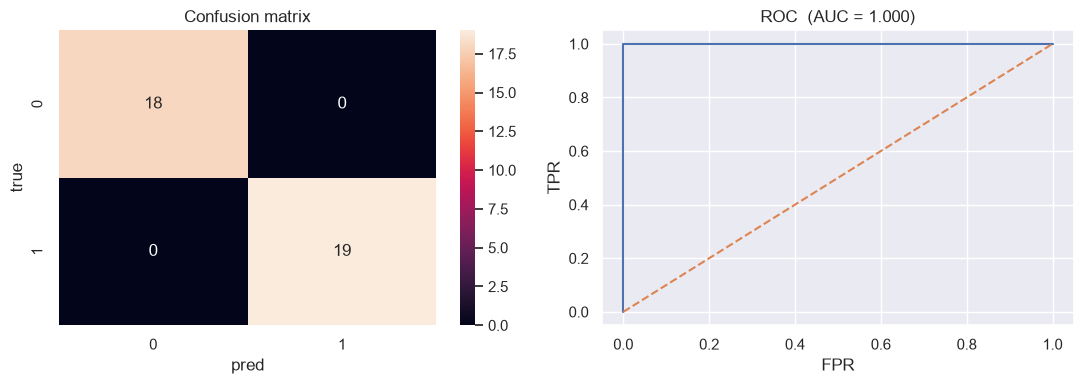

In [16]:
# Best by ROC-AUC: full report + confusion matrix + ROC curve
best_name = max(rows, key=lambda r: r["roc_auc"])["variant"]
best, cols = models[best_name]
print("best:", best_name)

d = model_df.dropna(subset=cols + ["is_high_value"])
Xa, Xb, ya, yb = train_test_split(d[cols], d["is_high_value"], test_size=0.2,
                                  random_state=7, stratify=d["is_high_value"])
pb, proba = best.predict(Xb), best.predict_proba(Xb)[:, 1]
print(classification_report(yb, pb, zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(yb, pb), annot=True, fmt="d", ax=ax[0])
ax[0].set_title("Confusion matrix"); ax[0].set_xlabel("pred"); ax[0].set_ylabel("true")
fpr, tpr, _ = roc_curve(yb, proba)
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], ls="--")
ax[1].set_title(f"ROC  (AUC = {roc_auc_score(yb, proba):.3f})")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
plt.tight_layout(); plt.show()

## Interpretation

**What happened.** 181 tiers, balanced target (50.3% high-value at the $100 cutoff). Grid
results: `odds + flags` already hits accuracy 0.97 / ROC-AUC 0.98; adding `tier_group` or
the ladder features pushes both to **1.000** on the 37-row held-out set; the depth-4 tree
lands at 0.97.

**Why the scores are perfect — and why that isn't a win.** `is_high_value` is derived from
`est_value_usd`, which is the `rough_estimate_v0` **ladder** — a deterministic step
function of exactly these attributes (odds band, numbered, autograph, tier group). So the
classifier isn't learning anything about the market; it's reconstructing the ladder rule,
and the classes are linearly separable by construction. Read the metrics as a "the
pipeline wiring works" check, not predictive skill.

**Key assumptions / where they fail.**
- *Label validity* — the biggest one. The target is a placeholder; every number here is
  provisional until `data/raw/tier_comps.csv` holds real eBay sold comps.
- *Decision boundary* — logistic regression assumes a roughly linear log-odds boundary.
  It works here only because the ladder thresholds line up with the features; on real,
  noisy comp values a tree / gradient-boosting model (hard $ cutoffs handled natively) is
  the better bet.
- *Independence* — no time axis, so no look-ahead leakage, but tiers within one product
  share a checklist design; a random split puts siblings on both sides. `GroupShuffleSplit`
  on `product_line` would be stricter.

**Risk-aware read.** For the real use — flagging which tiers to prioritise for comp
collection / which drive box EV — **recall on the positive class matters more than
precision**: a missed high-value tier under-states EV. Accuracy alone is weak (a coin-flip
scores ~50%); report recall and ROC-AUC. **Do not wire this classifier into the buy/pass
EV calc** while the label is synthetic.

**How to extend.** Refit on a real-comp label (expect a large drop and *meaningful*
scores); add `product_line`, then player/subject once comps exist (hw08: subject dominates
value); switch to gradient boosting; calibrate probabilities for a usable "P(high value)"
score per tier.